In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde

In [2]:
def sigmoid_alpha(x, alpha=1.0):
    return 1.0 / (1.0 + np.exp(-alpha * x))

# Change-of-variables formula for Y = sigmoid_alpha(X)
def transformed_pdf(y, mu, sigma, alpha=1.0):
    # x = (1/alpha) * ln(y/(1-y))
    x_val = (1/alpha) * np.log(y/(1 - y))
    pdf_x_val = norm.pdf(x_val, loc=mu, scale=sigma)
    # Jacobian = 1 / [alpha * y * (1-y)]
    jacobian = 1.0 / (alpha * y * (1.0 - y))
    return pdf_x_val * jacobian

def distribution_overlap(samples1, samples2, num_points=200):
    """
    Estimate the PDF overlap between two sample sets 
    using kernel density estimation and numerical integration 
    of the minimum of the two PDFs.

    Returns a value in [0, 1], 
    where 0 means no overlap at all, 
    and 1 means the two distributions are identical.
    """
    # Fit KDE to each set of samples
    kde1 = gaussian_kde(samples1)
    kde2 = gaussian_kde(samples2)

    # Determine a suitable grid over which to evaluate
    x_min = min(samples1.min(), samples2.min())
    x_max = max(samples1.max(), samples2.max())
    
    # Add a little margin so we capture extreme tails
    margin = 0.05 * (x_max - x_min)
    x_grid = np.linspace(x_min - margin, x_max + margin, num_points)

    # Evaluate the two PDFs on this grid
    pdf1 = kde1(x_grid)
    pdf2 = kde2(x_grid)

    # Compute the overlap by integrating the minimum of the two PDFs
    overlap_area = np.trapz(np.minimum(pdf1, pdf2), x_grid)
    return overlap_area

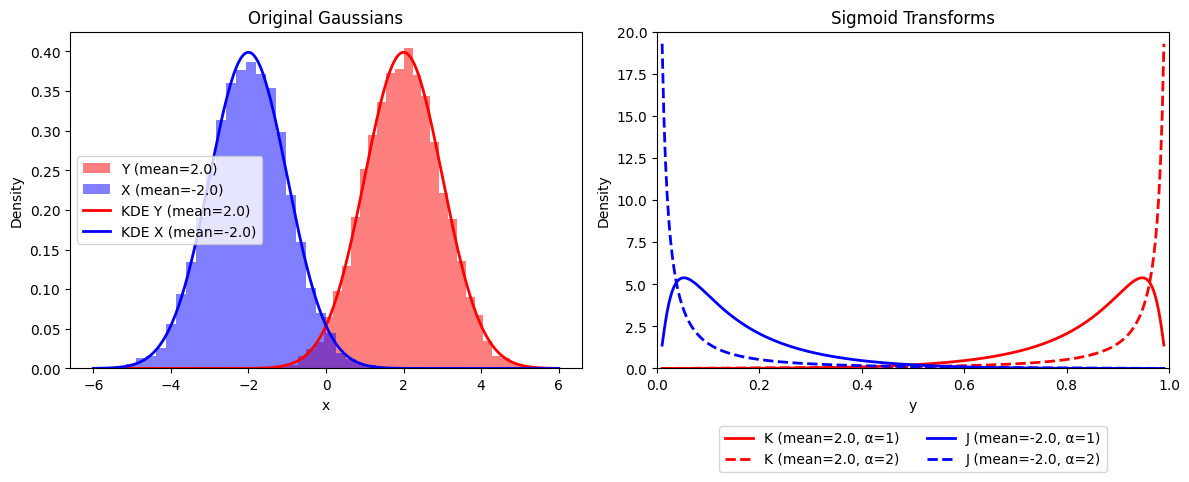

In [5]:
# Generate two Gaussian samples
mean1, std_dev1 = 2.0, 1.0
mean2, std_dev2 = -2.0, 1.0
alpha_values = [1.0, 2.0, 3.0]
n_samples = 10_000

samples1 = np.random.normal(loc=mean1, scale=std_dev1, size=n_samples)
samples2 = np.random.normal(loc=mean2, scale=std_dev2, size=n_samples)

# PDFs for each Gaussian
x_min = min(mean1, mean2) - 4
x_max = max(mean1, mean2) + 4
x = np.linspace(x_min, x_max, 300)

pdf_x1 = norm.pdf(x, loc=mean1, scale=std_dev1)
pdf_x2 = norm.pdf(x, loc=mean2, scale=std_dev2)

# Plot of the two Gaussians
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Original Gaussians")
plt.hist(samples1, bins=30, density=True, color='red', alpha=0.5, label=f"Y (mean={mean1})")
plt.hist(samples2, bins=30, density=True, color='blue', alpha=0.5, label=f"X (mean={mean2})")

plt.plot(x, pdf_x1, 'r-', lw=2, label=f"KDE Y (mean={mean1})")
plt.plot(x, pdf_x2, 'b-', lw=2, label=f"KDE X (mean={mean2})")

plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

# Sigmoid transforms
transformed1_alpha1 = sigmoid_alpha(samples1, alpha=1.0)
transformed1_alpha2 = sigmoid_alpha(samples1, alpha=2.0)
transformed2_alpha1 = sigmoid_alpha(samples2, alpha=1.0)
transformed2_alpha2 = sigmoid_alpha(samples2, alpha=2.0)

# Evaluate PDF on [0.01, 0.99] to avoid the extreme spikes
y = np.linspace(0.01, 0.99, 300)

pdf_y1_alpha1 = transformed_pdf(y, mean1, std_dev1, alpha=1.0)
pdf_y1_alpha2 = transformed_pdf(y, mean1, std_dev1, alpha=2.0)
pdf_y2_alpha1 = transformed_pdf(y, mean2, std_dev2, alpha=1.0)
pdf_y2_alpha2 = transformed_pdf(y, mean2, std_dev2, alpha=2.0)

plt.subplot(1, 2, 2)
plt.title("Sigmoid Transforms")

# A narrower bin width helps see the shape better
bins = np.linspace(0, 1, 50)

# plt.hist(transformed1_alpha1, bins=bins, density=True, alpha=0.3, label=f"Mean={mean1}, alpha=1")
# plt.hist(transformed1_alpha2, bins=bins, density=True, alpha=0.3, label=f"Mean={mean1}, alpha=2")
# plt.hist(transformed2_alpha1, bins=bins, density=True, alpha=0.3, label=f"Mean={mean2}, alpha=1")
# plt.hist(transformed2_alpha2, bins=bins, density=True, alpha=0.3, label=f"Mean={mean2}, alpha=2")

# Plot the theoretical PDFs using different line styles
plt.plot(y, pdf_y1_alpha1, 'r-', lw=2, label=f"K (mean={mean1}, α=1)")
plt.plot(y, pdf_y1_alpha2, 'r--', lw=2, label=f"K (mean={mean1}, α=2)")
plt.plot(y, pdf_y2_alpha1, 'b-', lw=2, label=f"J (mean={mean2}, α=1)")
plt.plot(y, pdf_y2_alpha2, 'b--', lw=2, label=f"J (mean={mean2}, α=2)")

# Restrict the y-axis to prevent huge spikes
plt.ylim(0, 20)  # Adjust as desired
plt.xlim(0, 1)

plt.xlabel("y")
plt.ylabel("Density")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()



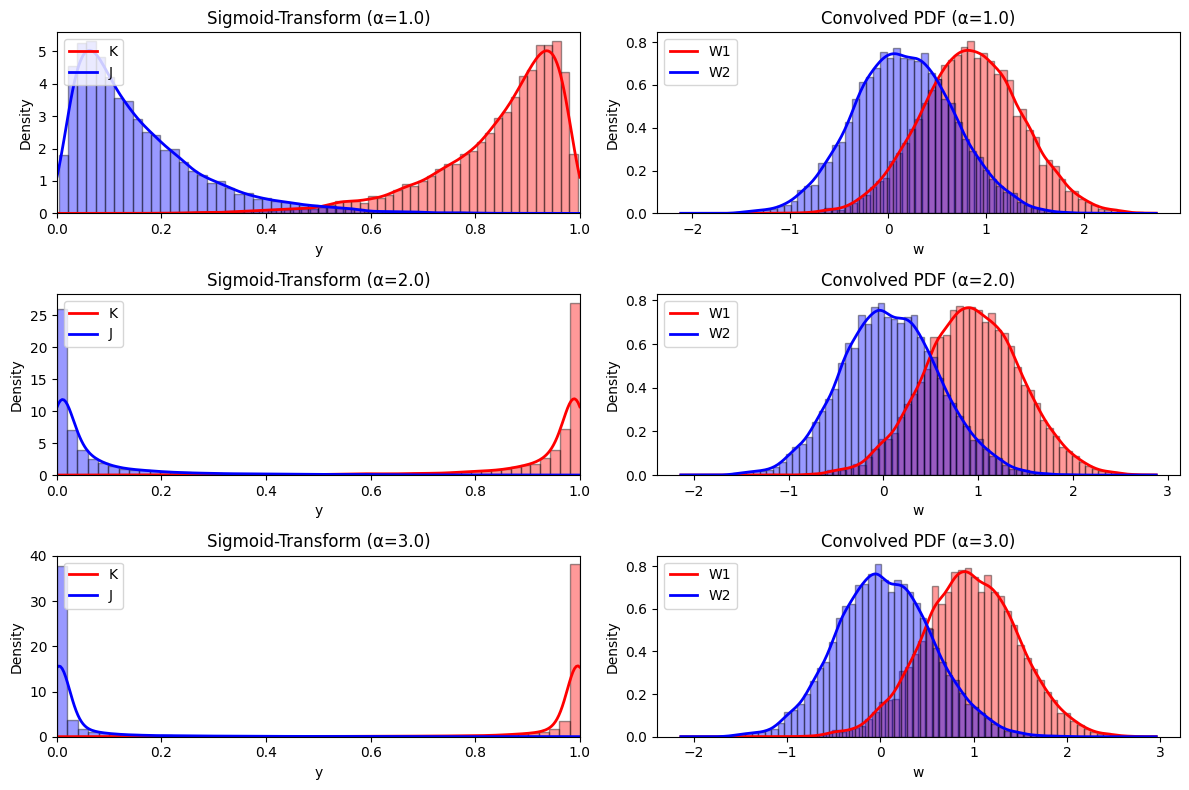

In [8]:
X1 = samples1  # X1
X2 = samples2 # X2

# Zero-mean Gaussian to convolve with
# ------------------------------------------------------------
tau = 0.5
Z = np.random.normal(0.0, tau, size=n_samples)

# We'll store both Y (transformed) and W (convolved) for plotting
Y_results = {}  # (alpha, 'X1') -> array of Y
W_results = {}  # (alpha, 'X1') -> array of W

for alpha in alpha_values:
    # Transform each X
    Y1 = sigmoid_alpha(X1, alpha=alpha)
    Y2 = sigmoid_alpha(X2, alpha=alpha)
    
    # Convolve with Z: W = Y + Z
    W1 = Y1 + Z
    W2 = Y2 + Z
    
    # Store in dictionaries
    Y_results[(alpha, 'X1')] = Y1
    Y_results[(alpha, 'X2')] = Y2
    
    W_results[(alpha, 'X1')] = W1
    W_results[(alpha, 'X2')] = W2

plt.figure(figsize=(12, 8))

for row_i, alpha in enumerate(alpha_values, start=1):
    plt.subplot(3, 2, 2*(row_i-1) + 1)
    plt.title(f"Sigmoid-Transform (α={alpha})")
    
    Y1 = Y_results[(alpha, 'X1')]
    Y2 = Y_results[(alpha, 'X2')]
    
    # Histograms (in [0,1])
    plt.hist(Y1, bins=50, density=True, color='red', alpha=0.4,edgecolor='black')
    plt.hist(Y2, bins=50, density=True, color='blue', alpha=0.4, edgecolor='black')
    
    # KDE lines
    # Build a grid in [0,1] (since Y in (0,1), though it can be near 0 or 1)
    y_grid = np.linspace(0, 1, 300)
    kde1 = gaussian_kde(Y1)
    kde2 = gaussian_kde(Y2)
    pdf1 = kde1(y_grid)
    pdf2 = kde2(y_grid)
    
    plt.plot(y_grid, pdf1, color='red', lw=2, label="K")
    plt.plot(y_grid, pdf2, color='blue', lw=2, label="J")
    
    plt.xlim(0, 1)
    plt.xlabel("y")
    plt.ylabel("Density")
    plt.legend(loc='upper left')
    
    # ------------------
    # Right subplot: W = Y + Z
    # ------------------
    plt.subplot(3, 2, 2*(row_i-1) + 2)
    plt.title(f"Convolved PDF (α={alpha})")
    
    W1 = W_results[(alpha, 'X1')]
    W2 = W_results[(alpha, 'X2')]
    
    # Histograms
    plt.hist(W1, bins=60, density=True, color='red', alpha=0.4, edgecolor='black')
    plt.hist(W2, bins=60, density=True, color='blue', alpha=0.4, edgecolor='black')
    
    # KDE lines
    w_min, w_max = min(W1.min(), W2.min()), max(W1.max(), W2.max())
    w_grid = np.linspace(w_min, w_max, 300)
    
    kde_w1 = gaussian_kde(W1)
    kde_w2 = gaussian_kde(W2)
    pdf_w1 = kde_w1(w_grid)
    pdf_w2 = kde_w2(w_grid)
    
    plt.plot(w_grid, pdf_w1, color='red', lw=2, label="W1")
    plt.plot(w_grid, pdf_w2, color='blue', lw=2, label="W2")
    
    plt.xlabel("w")
    plt.ylabel("Density")
    plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [12]:
print(f'Distribution overlap of original gaussians: {distribution_overlap(X1, X2)}')
print(f'Distribution overlap of sigmoid-transformed gaussians for alpha=1: {distribution_overlap(Y_results[(1, "X1")], Y_results[(1, "X2")])}')
print(f'Distribution overlap of sigmoid-transformed gaussians for alpha=2: {distribution_overlap(Y_results[(2, "X1")], Y_results[(2, "X2")])}')
print(f'Distribution overlap of sigmoid-transformed gaussians for alpha=3: {distribution_overlap(Y_results[(3, "X1")], Y_results[(3, "X2")])}')

Distribution overlap of original gaussians: 0.04712096681068627
Distribution overlap of sigmoid-transformed gaussians for alpha=1: 0.0447697478492452
Distribution overlap of sigmoid-transformed gaussians for alpha=2: 0.04404889548190141
Distribution overlap of sigmoid-transformed gaussians for alpha=3: 0.043868695306648886


In [13]:
print(f'Distribution overlap of Ws for alpha=1: {distribution_overlap(W_results[(1, "X1")], W_results[(1, "X2")])}')
print(f'Distribution overlap of Ws for alpha=2: {distribution_overlap(W_results[(2, "X1")], W_results[(2, "X2")])}')
print(f'Distribution overlap of Ws for alpha=3: {distribution_overlap(W_results[(3, "X1")], W_results[(3, "X2")])}')

Distribution overlap of Ws for alpha=1: 0.5084959273456007
Distribution overlap of Ws for alpha=2: 0.4020532172194571
Distribution overlap of Ws for alpha=3: 0.37400815494198975
